In [6]:
!pip install pandas numpy matplotlib seaborn plotly

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set()

In [8]:
url = "https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv"

df = pd.read_csv(url)
df.head()

,Date,Country,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,0,0,0
1,2020-01-23,Afghanistan,0,0,0
2,2020-01-24,Afghanistan,0,0,0
3,2020-01-25,Afghanistan,0,0,0
4,2020-01-26,Afghanistan,0,0,0


In [9]:

df.columns = ['Date', 'Country', 'Confirmed', 'Recovered', 'Deaths']


df['Date'] = pd.to_datetime(df['Date'])


df['Active'] = df['Confirmed'] - df['Recovered'] - df['Deaths']

df.head()

,Date,Country,Confirmed,Recovered,Deaths,Active
0,2020-01-22,Afghanistan,0,0,0,0
1,2020-01-23,Afghanistan,0,0,0,0
2,2020-01-24,Afghanistan,0,0,0,0
3,2020-01-25,Afghanistan,0,0,0,0
4,2020-01-26,Afghanistan,0,0,0,0


In [10]:
print("Total Confirmed:", df['Confirmed'].sum())
print("Total Deaths:", df['Deaths'].sum())
print("Total Recovered:", df['Recovered'].sum())

df.describe()

Total Confirmed: 118939403514
Total Deaths: 2261860890
Total Recovered: 23491455947


,Date,Confirmed,Recovered,Deaths,Active
count,161568,1.615680e+05,1.615680e+05,161568.000000,1.615680e+05
mean,2021-03-04 11:59:59.999999232,7.361569e+05,1.453967e+05,13999.436089,5.767608e+05
min,2020-01-22 00:00:00,0.000000e+00,0.000000e+00,0.000000,-1.638280e+05
25%,2020-08-12 18:00:00,1.220000e+03,0.000000e+00,17.000000,1.680000e+02
50%,2021-03-04 12:00:00,2.369200e+04,1.260000e+02,365.000000,6.015500e+03
75%,2021-09-24 06:00:00,2.558420e+05,1.797225e+04,4509.000000,7.974525e+04
max,2022-04-16 00:00:00,8.062512e+07,3.097475e+07,988609.000000,7.963651e+07
std,NaN,3.578884e+06,9.748275e+05,59113.581271,3.387235e+06


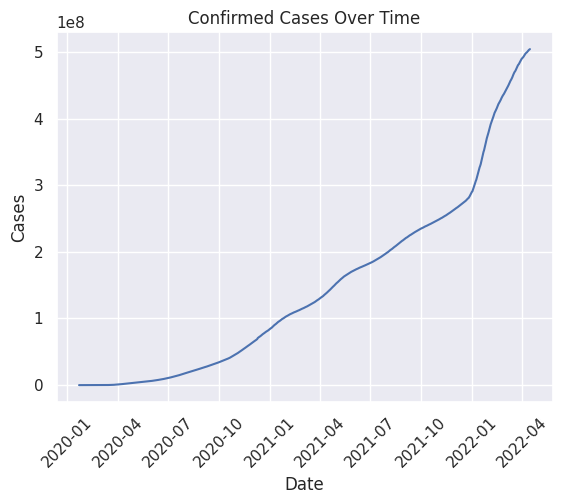

In [11]:
trend = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

plt.figure()
plt.plot(trend['Date'], trend['Confirmed'])
plt.title("Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.xticks(rotation=45)
plt.show()

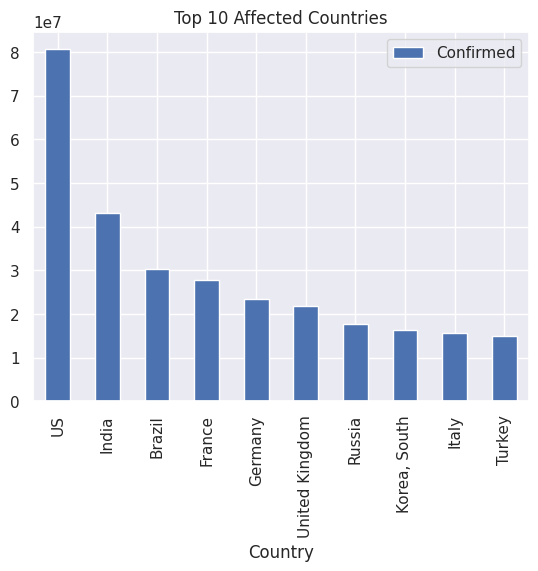

In [12]:
top_countries = df.groupby('Country')[['Confirmed']].max().sort_values(by='Confirmed', ascending=False).head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Affected Countries")
plt.show()

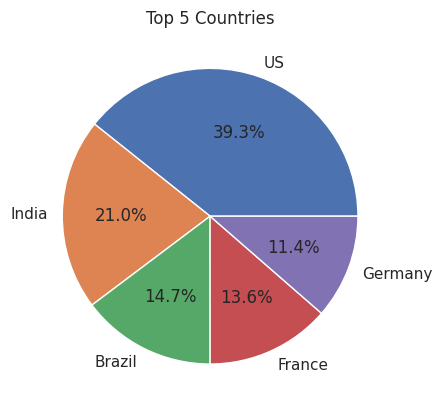

In [13]:
latest = df.groupby('Country').max().sort_values(by='Confirmed', ascending=False).head(5)

plt.figure()
plt.pie(latest['Confirmed'], labels=latest.index, autopct='%1.1f%%')
plt.title("Top 5 Countries")
plt.show()

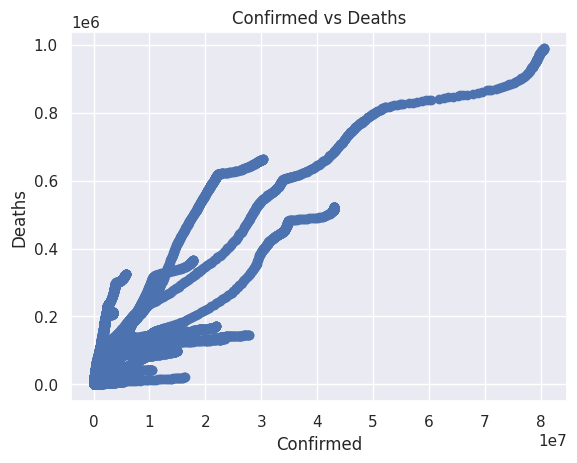

In [14]:
plt.figure()
plt.scatter(df['Confirmed'], df['Deaths'])
plt.xlabel("Confirmed")
plt.ylabel("Deaths")
plt.title("Confirmed vs Deaths")
plt.show()

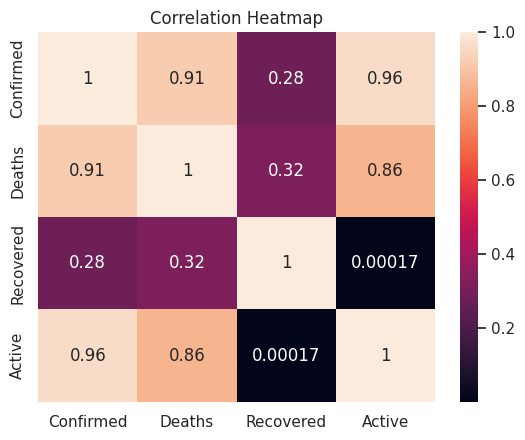

In [15]:
corr = df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()